# 04 — Model Training & Evaluation
Historical 7-day rainfall forecasting for 6 Sangrur blocks.
Target `target_7d_rainfall_mm` = observed CHIRPS D+1..D+7; features use only information
available at issue date D. Chronological splits (train JJAS 2016–19 / val JJAS 2021–22 /
test JJAS 2023–25); test stays unseen until final evaluation. Baselines first, then
Random Forest / XGBoost / LightGBM — ML must earn its place against them.

In [1]:
# Cell 2 — Imports (no installs inside the notebook)
import json
import warnings
from datetime import date
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             log_loss, mean_absolute_error, mean_squared_error, r2_score)

warnings.filterwarnings("ignore")
print("imports ok")


imports ok


In [2]:
# Cell 3 — Environment / project root / seed
import sys

CWD = Path.cwd().resolve()
PROJECT = CWD.parent if CWD.name == "notebooks" else Path(".").resolve()
assert (PROJECT / "data" / "processed").exists(), PROJECT
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)
print(f"Python: {sys.version.split()[0]}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | sklearn {sklearn.__version__}")
print(f"xgboost {xgb.__version__} | lightgbm {lgb.__version__} | joblib {joblib.__version__}")
print(f"project root: {PROJECT}")
print(f"random seed: {SEED}")


Python: 3.11.9
pandas 2.3.3 | numpy 2.4.1 | sklearn 1.8.0
xgboost 3.2.0 | lightgbm 4.7.0 | joblib 1.5.3
project root: C:\Users\Swarnim\Desktop\ML projects\saarthi-2
random seed: 42


In [3]:
# Cell 4 — Load final ML dataset (prefer Parquet, never modify source)
pq = PROJECT / "data" / "processed" / "final_ml_dataset.parquet"
cs = PROJECT / "data" / "processed" / "final_ml_dataset.csv"
if pq.exists():
    DATA_PATH, df = pq, pd.read_parquet(pq)
elif cs.exists():
    DATA_PATH, df = cs, pd.read_csv(cs, parse_dates=["forecast_date"])
else:
    raise FileNotFoundError("final_ml_dataset parquet/csv missing — run Notebook 03")
df["forecast_date"] = pd.to_datetime(df["forecast_date"])
print(f"path: {DATA_PATH}")
print(f"shape: {df.shape}")
print(f"columns ({len(df.columns)}): {df.columns.tolist()}")
print(f"date range: {df['forecast_date'].min().date()} .. {df['forecast_date'].max().date()}")
print(f"blocks ({df['block'].nunique()}): {sorted(df['block'].unique())}")


path: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\processed\final_ml_dataset.parquet
shape: (6588, 34)
columns (34): ['forecast_date', 'block', 'gefs_d1', 'gefs_d2', 'gefs_d3', 'gefs_d4', 'gefs_d5', 'gefs_d6', 'gefs_d7', 'gefs_3d_total', 'gefs_7d_total', 'rain_1d', 'rain_3d', 'rain_7d', 'rain_14d', 'rain_30d', 'rain_lag_1', 'rain_lag_2', 'rain_lag_3', 'rain_lag_4', 'rain_lag_5', 'rain_lag_6', 'rain_lag_7', 'enso_value', 'sin_day_of_year', 'cos_day_of_year', 'soil_clay', 'soil_sand', 'soil_silt', 'soil_soc', 'soil_ph', 'latitude', 'longitude', 'target_7d_rainfall_mm']
date range: 2016-06-01 .. 2025-09-30
blocks (6): ['Dhuri', 'Lehra', 'Malerkotla', 'Moonak', 'Sangrur', 'Sunam']


In [4]:
# Cell 5 — Dataset structure audit (verify, never silently repair)
EXPECTED_BLOCKS = {"Dhuri", "Lehra", "Malerkotla", "Moonak", "Sangrur", "Sunam"}
assert pd.api.types.is_datetime64_any_dtype(df["forecast_date"]), "forecast_date not datetime"
assert "target_7d_rainfall_mm" in df.columns, "target missing"
assert set(df["block"].unique()) == EXPECTED_BLOCKS, set(df["block"].unique())
assert int(df.duplicated(subset=["forecast_date", "block"]).sum()) == 0, "duplicate keys"
assert not any(c.startswith("Unnamed") for c in df.columns), "stray index column"
print("forecast_date: datetime OK | target present | 6 blocks OK | 0 duplicate keys | no index cols")
print("\nrows per block:")
print(df["block"].value_counts().sort_index().to_string())
print(f"\nunique dates: {df['forecast_date'].nunique()}")


forecast_date: datetime OK | target present | 6 blocks OK | 0 duplicate keys | no index cols

rows per block:
block
Dhuri         1098
Lehra         1098
Malerkotla    1098
Moonak        1098
Sangrur       1098
Sunam         1098

unique dates: 1098


In [5]:
# Cell 6 — Target + explicit feature list (identifiers/metadata excluded, block never numeric)
TARGET = "target_7d_rainfall_mm"
NON_FEATURES = {"forecast_date", "block", TARGET}
FEATURES = [c for c in df.columns if c not in NON_FEATURES]
assert TARGET not in FEATURES and "forecast_date" not in FEATURES and "block" not in FEATURES
obj = [c for c in FEATURES if not pd.api.types.is_numeric_dtype(df[c])]
assert not obj, f"non-numeric predictors: {obj}"
assert not any("actual" in c or "future" in c for c in FEATURES), "suspicious feature names"
print(f"TARGET = {TARGET}")
print(f"FEATURES ({len(FEATURES)}):")
for i, c in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {c}")


TARGET = target_7d_rainfall_mm
FEATURES (31):
   1. gefs_d1
   2. gefs_d2
   3. gefs_d3
   4. gefs_d4
   5. gefs_d5
   6. gefs_d6
   7. gefs_d7
   8. gefs_3d_total
   9. gefs_7d_total
  10. rain_1d
  11. rain_3d
  12. rain_7d
  13. rain_14d
  14. rain_30d
  15. rain_lag_1
  16. rain_lag_2
  17. rain_lag_3
  18. rain_lag_4
  19. rain_lag_5
  20. rain_lag_6
  21. rain_lag_7
  22. enso_value
  23. sin_day_of_year
  24. cos_day_of_year
  25. soil_clay
  26. soil_sand
  27. soil_silt
  28. soil_soc
  29. soil_ph
  30. latitude
  31. longitude


In [6]:
# Cell 7 — Feature audit (flag, never auto-delete)
rows = []
for c in FEATURES:
    s = pd.to_numeric(df[c], errors="coerce")
    rows.append({"feature": c, "dtype": str(df[c].dtype),
                 "missing_%": round(s.isna().mean() * 100, 2),
                 "n_unique": int(s.nunique()), "min": s.min(), "max": s.max(),
                 "inf": int(np.isinf(s.dropna()).sum())})
audit = pd.DataFrame(rows)
print(audit.to_string(index=False))
print("\nflags:")
print(f"  all-NaN cols: {[c for c in FEATURES if df[c].isna().all()] or 'none'}")
print(f"  constant cols: {audit[audit['n_unique'] <= 1]['feature'].tolist() or 'none'}")
print(f"  infinite values: {int(audit['inf'].sum())}")
print(f"  object/string features: {[c for c in FEATURES if df[c].dtype == object] or 'none'}")


        feature   dtype  missing_%  n_unique        min        max  inf
        gefs_d1 float64        0.0      5193   0.000000  78.805127    0
        gefs_d2 float64        0.0      5310   0.000000  91.424455    0
        gefs_d3 float64        0.0      5433   0.000000  55.639217    0
        gefs_d4 float64        0.0      5607   0.000000  91.152714    0
        gefs_d5 float64        0.0      5684   0.000000  96.776711    0
        gefs_d6 float64        0.0      5830   0.000000 109.913911    0
        gefs_d7 float64        0.0      5953   0.000000  35.814475    0
  gefs_3d_total float64        0.0      5892   0.000000 129.974941    0
  gefs_7d_total float64        0.0      6387   0.000000 226.617519    0
        rain_1d float64        0.0      5571   0.000000  99.829380    0
        rain_3d float64        0.0      5867   0.000000 147.448369    0
        rain_7d float64        0.0      6100   0.000000 250.094466    0
       rain_14d float64        0.0      6158   0.000000 317.8488

missing: 0 | min 0.00 | max 250.09 | mean 32.02 | median 19.13 | std 33.77
0.10      0.97
0.25      6.14
0.33      9.18
0.50     19.13
0.66     38.65
0.75     50.09
0.90     80.01
0.95     99.53
0.99    143.15


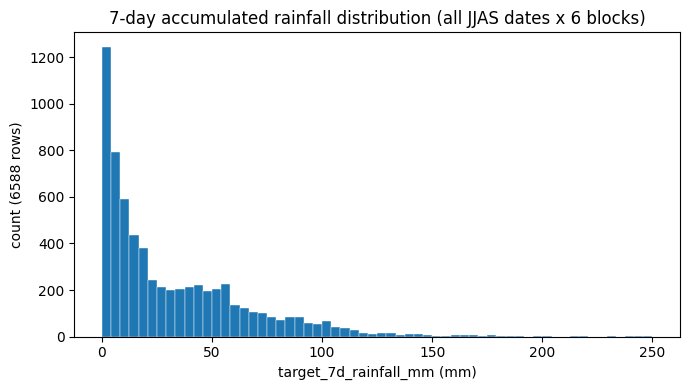

In [7]:
# Cell 8 — Target audit + distribution
t = pd.to_numeric(df[TARGET], errors="coerce")
assert t.notna().all(), "missing targets present"
assert (t >= 0).all(), "negative rainfall present"
print(f"missing: {int(t.isna().sum())} | min {t.min():.2f} | max {t.max():.2f} | "
      f"mean {t.mean():.2f} | median {t.median():.2f} | std {t.std():.2f}")
print(t.quantile([0.1, 0.25, 0.33, 0.5, 0.66, 0.75, 0.9, 0.95, 0.99]).round(2).to_string())
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(t, bins=60, edgecolor="white", linewidth=0.3)
ax.set_xlabel("target_7d_rainfall_mm (mm)")
ax.set_ylabel("count (6588 rows)")
ax.set_title("7-day accumulated rainfall distribution (all JJAS dates x 6 blocks)")
plt.tight_layout()
plt.show()


## Chronological splits (never random)
Train JJAS 2016–2019 → Validation JJAS 2021–2022 → Test JJAS 2023–2025. 2020 excluded by design.

In [8]:
# Cell 9 — Chronological split by year
train_df = df[df["forecast_date"].dt.year.between(2016, 2019)].copy()
val_df = df[df["forecast_date"].dt.year.between(2021, 2022)].copy()
test_df = df[df["forecast_date"].dt.year.between(2023, 2025)].copy()
assert len(train_df) + len(val_df) + len(test_df) == len(df), "split coverage gap/overlap"
assert train_df["forecast_date"].max() < val_df["forecast_date"].min() <= val_df["forecast_date"].max() < test_df["forecast_date"].min()
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert set(d["block"].unique()) == EXPECTED_BLOCKS, name
    print(f"{name:5s}: {d['forecast_date'].min().date()} .. {d['forecast_date'].max().date()} | "
          f"{d['forecast_date'].nunique()} dates | {len(d)} rows | 6 blocks")


train: 2016-06-01 .. 2019-09-30 | 488 dates | 2928 rows | 6 blocks
val  : 2021-06-01 .. 2022-09-30 | 244 dates | 1464 rows | 6 blocks
test : 2023-06-01 .. 2025-09-30 | 366 dates | 2196 rows | 6 blocks


In [9]:
# Cell 10 — X/y (identical columns, numeric; target never in X)
def make_xy(frame):
    X = frame[FEATURES].copy().astype(float)
    y = pd.to_numeric(frame[TARGET], errors="coerce").astype(float)
    return X, y

X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns) == FEATURES
assert TARGET not in X_train.columns
assert not any(pd.api.types.is_datetime64_any_dtype(X_train[c]) or X_train[c].dtype == object for c in FEATURES)
assert all(np.isfinite(X_train[c]).all() or X_train[c].isna().any() for c in FEATURES)
print(f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")
print("target in X: False | datetime/object cols in X: none")


X_train (2928, 31) | X_val (1464, 31) | X_test (2196, 31)
target in X: False | datetime/object cols in X: none


In [10]:
# Cell 11 — Missing-value handling (fit on train only; GEFS never zero-filled)
miss = pd.DataFrame({"train_%": X_train.isna().mean() * 100, "val_%": X_val.isna().mean() * 100,
                     "test_%": X_test.isna().mean() * 100})
print(miss[miss.max(axis=1) > 0].to_string() if (miss > 0).any().any() else "No missing predictors in any split.")
NEEDS_IMPUTATION = bool((X_train.isna().sum() > 0).any())
if NEEDS_IMPUTATION:
    from sklearn.impute import SimpleImputer
    imp = SimpleImputer(strategy="median")
    X_train = pd.DataFrame(imp.fit_transform(X_train), columns=FEATURES, index=X_train.index)
    X_val = pd.DataFrame(imp.transform(X_val), columns=FEATURES, index=X_val.index)
    X_test = pd.DataFrame(imp.transform(X_test), columns=FEATURES, index=X_test.index)
    print("Median imputation fit on X_train only; applied to val/test.")
else:
    imp = None
    print("No imputation needed — all splits complete. "
          "(Pipeline stores unavailable GEFS as NaN, never zero; here nothing is missing.)")


No missing predictors in any split.
No imputation needed — all splits complete. (Pipeline stores unavailable GEFS as NaN, never zero; here nothing is missing.)


## Baselines (meaningful references ML must beat)
Climatology (train seasonal means), persistence (`rain_7d`), raw GEFS (`gefs_7d_total`).
All baseline parameters come from TRAIN only.

In [11]:
# Cell 12 — Climatology baseline (day-of-year means from TRAIN targets only)
doy_mean = y_train.groupby(train_df["forecast_date"].dt.dayofyear).mean()
train_global_mean = float(y_train.mean())
print(f"doy groups in train: {len(doy_mean)} | global train mean: {train_global_mean:.2f} mm")

def predict_climatology(dates):
    return np.array([doy_mean.get(d.dayofyear, train_global_mean) for d in pd.to_datetime(dates)])

clim_val = predict_climatology(val_df["forecast_date"])
clim_test = predict_climatology(test_df["forecast_date"])
print(f"val/test climatology predictions ready ({len(clim_val)}/{len(clim_test)})")


doy groups in train: 123 | global train mean: 31.01 mm
val/test climatology predictions ready (1464/2196)


In [12]:
# Cell 13 — Persistence baseline (rain_7d: last-7-days observed rainfall as next-7-days guess)
assert "rain_7d" in FEATURES
pers_val = X_val["rain_7d"].to_numpy()
pers_test = X_test["rain_7d"].to_numpy()
assert np.isfinite(pers_val).all() and np.isfinite(pers_test).all()
print(f"persistence = rain_7d (observed <= D only; no test tuning). val mean {pers_val.mean():.2f}, test mean {pers_test.mean():.2f}")


persistence = rain_7d (observed <= D only; no test tuning). val mean 30.19, test mean 34.51


In [13]:
# Cell 14 — Raw GEFS baseline (gefs_7d_total = sum of valid D+1..D+7 leads, no lead-0)
assert "gefs_7d_total" in FEATURES, "gefs_7d_total missing"
assert (X_val[[f"gefs_d{i}" for i in range(1, 8)]].notna().all().all()
        and X_test[[f"gefs_d{i}" for i in range(1, 8)]].notna().all().all())
gefs_val = X_val["gefs_7d_total"].to_numpy()
gefs_test = X_test["gefs_7d_total"].to_numpy()
print(f"raw GEFS = gefs_7d_total (issued at D, no observations). val mean {gefs_val.mean():.2f}, test mean {gefs_test.mean():.2f}")


raw GEFS = gefs_7d_total (issued at D, no observations). val mean 26.07, test mean 30.29


In [14]:
# Cell 15 — Baseline evaluation (MAE / RMSE / R2 / MBE)
def reg_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2": r2_score(y_true, y_pred),
            "Bias": float(np.mean(y_pred - y_true))}

baseline_rows = []
for name, pv, pt in [("Climatology", clim_val, clim_test),
                     ("Persistence", pers_val, pers_test),
                     ("Raw GEFS", gefs_val, gefs_test)]:
    for split, y, p in [("val", y_val, pv), ("test", y_test, pt)]:
        m = reg_metrics(y, p)
        baseline_rows.append({"Model": name, "Split": split, **{k: round(v, 3) for k, v in m.items()}})
baselines = pd.DataFrame(baseline_rows)
print(baselines.to_string(index=False))


      Model Split    MAE   RMSE     R2   Bias
Climatology   val 24.493 30.737  0.017  0.519
Climatology  test 24.640 35.645  0.097 -3.379
Persistence   val 26.915 37.106 -0.432 -0.304
Persistence  test 30.536 44.375 -0.399  0.128
   Raw GEFS   val 19.031 26.955  0.244 -4.429
   Raw GEFS  test 19.539 29.606  0.377 -4.089


## Machine learning (lightweight, fixed seeds, no test tuning)

In [15]:
# Cell 16 — Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=4,
                           n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)
rf_val = rf.predict(X_val)
rf_test = rf.predict(X_test)
print(f"RF val MAE {mean_absolute_error(y_val, rf_val):.3f} | test MAE {mean_absolute_error(y_test, rf_test):.3f}")


RF val MAE 22.216 | test MAE 20.176


In [16]:
# Cell 17 — XGBoost (early stopping on VALIDATION only)
xgb_reg = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=SEED, n_jobs=-1, early_stopping_rounds=50)
xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"best iteration: {xgb_reg.best_iteration}")
xgb_val = xgb_reg.predict(X_val)
xgb_test = xgb_reg.predict(X_test)
print(f"XGB val MAE {mean_absolute_error(y_val, xgb_val):.3f} | test MAE {mean_absolute_error(y_test, xgb_test):.3f}")


best iteration: 37
XGB val MAE 21.636 | test MAE 21.082


In [17]:
# Cell 18 — LightGBM
lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, max_depth=8,
                         feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
                         random_state=SEED, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_val = lgbm.predict(X_val)
lgbm_test = lgbm.predict(X_test)
print(f"LGBM val MAE {mean_absolute_error(y_val, lgbm_val):.3f} | test MAE {mean_absolute_error(y_test, lgbm_test):.3f}")


LGBM val MAE 23.089 | test MAE 21.344


In [18]:
# Cell 19 — Model comparison (all models x val/test, sorted by val MAE)
ml_rows = []
for name, pv, pt in [("Random Forest", rf_val, rf_test),
                     ("XGBoost", xgb_val, xgb_test),
                     ("LightGBM", lgbm_val, lgbm_test)]:
    for split, y, p in [("val", y_val, pv), ("test", y_test, pt)]:
        m = reg_metrics(y, p)
        ml_rows.append({"Model": name, "Split": split, **{k: round(v, 3) for k, v in m.items()}})
comparison = pd.concat([baselines, pd.DataFrame(ml_rows)], ignore_index=True)
val_order = comparison[comparison["Split"] == "val"].sort_values("MAE")["Model"].tolist()
print(comparison.sort_values(["Split", "MAE"]).to_string(index=False))
print(f"\nval-MAE ranking: {val_order}")


        Model Split    MAE   RMSE     R2   Bias
     Raw GEFS  test 19.539 29.606  0.377 -4.089
Random Forest  test 20.176 29.499  0.382 -3.364
      XGBoost  test 21.082 30.097  0.356 -2.604
     LightGBM  test 21.344 30.622  0.334 -1.656
  Climatology  test 24.640 35.645  0.097 -3.379
  Persistence  test 30.536 44.375 -0.399  0.128
     Raw GEFS   val 19.031 26.955  0.244 -4.429
      XGBoost   val 21.636 27.469  0.215  1.129
Random Forest   val 22.216 28.734  0.141  0.779
     LightGBM   val 23.089 29.669  0.084  3.443
  Climatology   val 24.493 30.737  0.017  0.519
  Persistence   val 26.915 37.106 -0.432 -0.304

val-MAE ranking: ['Raw GEFS', 'XGBoost', 'Random Forest', 'LightGBM', 'Climatology', 'Persistence']


In [19]:
# Cell 20 — Model selection on VALIDATION MAE only (honest: baselines may win)
val_mae = comparison[comparison["Split"] == "val"].set_index("Model")["MAE"]
WINNER_NAME = val_mae.idxmin()
test_row = comparison[(comparison["Split"] == "test") & (comparison["Model"] == WINNER_NAME)].iloc[0]
clim_test_mae = float(comparison[(comparison["Split"] == "test") & (comparison["Model"] == "Climatology")]["MAE"].iloc[0])
best_base_test = float(comparison[comparison["Split"] == "test"].query("Model in ['Climatology','Persistence','Raw GEFS']")["MAE"].min())
print(f"WINNER (lowest val MAE): {WINNER_NAME} (val MAE {val_mae.min():.3f})")
print(f"  test MAE {test_row['MAE']:.3f} | RMSE {test_row['RMSE']:.3f} | R2 {test_row['R2']:.3f} | Bias {test_row['Bias']:.3f}")
print(f"  vs climatology test MAE {clim_test_mae:.3f}: "
      f"{(clim_test_mae - test_row['MAE']) / clim_test_mae * 100:+.1f}%")
print(f"  vs best baseline test MAE {best_base_test:.3f}: "
      f"{(best_base_test - test_row['MAE']) / best_base_test * 100:+.1f}%")
if WINNER_NAME in ("Random Forest", "XGBoost", "LightGBM") and test_row["MAE"] < best_base_test:
    print("  ML improves over the strongest baseline on unseen test data.")
else:
    print(f"  Honest result: {WINNER_NAME} (a simple baseline) matches/beats all ML models.")
    print("  ML does not add skill over the raw forecast here; reported as-is, not hidden.")

# Point predictions for every candidate (train/val/test) + estimator registry.
# Baselines are rules (no estimator); ML models are fitted regressors.
PREDS_TRAIN = {"Climatology": predict_climatology(train_df["forecast_date"]),
               "Persistence": X_train["rain_7d"].to_numpy(),
               "Raw GEFS": X_train["gefs_7d_total"].to_numpy(),
               "Random Forest": rf.predict(X_train),
               "XGBoost": xgb_reg.predict(X_train),
               "LightGBM": lgbm.predict(X_train)}
PREDS_VAL = {"Climatology": clim_val, "Persistence": pers_val, "Raw GEFS": gefs_val,
             "Random Forest": rf_val, "XGBoost": xgb_val, "LightGBM": lgbm_val}
PREDS_TEST = {"Climatology": clim_test, "Persistence": pers_test, "Raw GEFS": gefs_test,
              "Random Forest": rf_test, "XGBoost": xgb_test, "LightGBM": lgbm_test}
ESTIMATORS = {"Random Forest": rf, "XGBoost": xgb_reg, "LightGBM": lgbm}
ML_NAMES = ["Random Forest", "XGBoost", "LightGBM"]
BEST_ML_NAME = val_mae[ML_NAMES].idxmin()
print(f"best ML model by val MAE: {BEST_ML_NAME}")


WINNER (lowest val MAE): Raw GEFS (val MAE 19.031)
  test MAE 19.539 | RMSE 29.606 | R2 0.377 | Bias -4.089
  vs climatology test MAE 24.640: +20.7%
  vs best baseline test MAE 19.539: +0.0%
  Honest result: Raw GEFS (a simple baseline) matches/beats all ML models.
  ML does not add skill over the raw forecast here; reported as-is, not hidden.
best ML model by val MAE: XGBoost


## Probabilistic LOW / NORMAL / HIGH categories (thresholds + calibration from TRAIN only)

In [20]:
# Cell 21 — Category thresholds from TRAINING targets only (p33 / p66)
T33, T66 = float(y_train.quantile(1 / 3)), float(y_train.quantile(2 / 3))
print(f"LOW:    target <  {T33:.2f} mm")
print(f"NORMAL: {T33:.2f} <= target <= {T66:.2f} mm")
print(f"HIGH:   target >  {T66:.2f} mm")
print("(percentiles of train targets; val/test targets never used)")


LOW:    target <  10.94 mm
NORMAL: 10.94 <= target <= 34.66 mm
HIGH:   target >  34.66 mm
(percentiles of train targets; val/test targets never used)


In [21]:
# Cell 22 — Actual categories + distributions
def categorize(s):
    s = np.asarray(s, float)
    return np.where(s < T33, "LOW", np.where(s > T66, "HIGH", "NORMAL"))

actual_train, actual_val, actual_test = categorize(y_train), categorize(y_val), categorize(y_test)
for name, a in [("train", actual_train), ("val", actual_val), ("test", actual_test)]:
    u, c = np.unique(a, return_counts=True)
    print(f"{name:5s}: " + ", ".join(f"{k} {v} ({v / len(a) * 100:.1f}%)" for k, v in zip(u, c)))


train: HIGH 976 (33.3%), LOW 976 (33.3%), NORMAL 976 (33.3%)
val  : HIGH 567 (38.7%), LOW 613 (41.9%), NORMAL 284 (19.4%)
test : HIGH 880 (40.1%), LOW 838 (38.2%), NORMAL 478 (21.8%)


In [22]:
# Cell 23 — Real probabilities via winner's TRAIN residual distribution (training info only)
# Predictive distribution for point forecast p: p + e, e ~ ECDF(train residuals of WINNER).
# prob_low = P(p+e < T33); prob_high = P(p+e > T66); prob_normal = rest. Never 100%-hard labels.
WINNER_EST = ESTIMATORS.get(WINNER_NAME)  # None for rule-based baselines
winner_train_point = PREDS_TRAIN[WINNER_NAME]
winner_val_point = PREDS_VAL[WINNER_NAME]
winner_test_point = PREDS_TEST[WINNER_NAME]
train_resid = np.sort(np.asarray(y_train, float) - np.asarray(winner_train_point, float))
print(f"train residuals: n={len(train_resid)}, mean {train_resid.mean():.3f}, std {train_resid.std():.3f}")
EPS = 1e-6

def predictive_probs(point_preds):
    point_preds = np.asarray(point_preds, float)
    p_low = np.searchsorted(train_resid, T33 - point_preds, side="right") / len(train_resid)
    p_high = 1.0 - np.searchsorted(train_resid, T66 - point_preds, side="right") / len(train_resid)
    p_normal = 1.0 - p_low - p_high
    P = np.clip(np.column_stack([p_low, p_normal, p_high]), EPS, 1 - EPS)
    return P / P.sum(axis=1, keepdims=True)

P_val, P_test = predictive_probs(winner_val_point), predictive_probs(winner_test_point)
print("val mean probs (low/normal/high):", P_val.mean(axis=0).round(3))
print("test mean probs (low/normal/high):", P_test.mean(axis=0).round(3))
print(f"row sums ~ 1: val {P_val.sum(axis=1)[:3].round(6)}, test {P_test.sum(axis=1)[:3].round(6)}")
pred_val_cat = np.array(["LOW", "NORMAL", "HIGH"])[P_val.argmax(axis=1)]
pred_test_cat = np.array(["LOW", "NORMAL", "HIGH"])[P_test.argmax(axis=1)]


train residuals: n=2928, mean 4.161, std 27.995
val mean probs (low/normal/high): [0.315 0.285 0.4  ]
test mean probs (low/normal/high): [0.326 0.253 0.421]
row sums ~ 1: val [1. 1. 1.], test [1. 1. 1.]


In [23]:
# Cell 24 — Probabilistic evaluation (val + test; nothing tuned on test)
from sklearn.preprocessing import LabelBinarizer
CATS = ["LOW", "NORMAL", "HIGH"]

def brier_score(P, y_true):
    Y = LabelBinarizer().fit_transform(y_true)
    if Y.shape[1] == 1:
        Y = np.hstack([1 - Y, Y])  # degenerate guard (not expected with 3 populated classes)
    return float(np.mean(np.sum((P - Y) ** 2, axis=1)))

cat_rows = []
for split, yt, yp, P in [("val", actual_val, pred_val_cat, P_val), ("test", actual_test, pred_test_cat, P_test)]:
    cat_rows.append({"Split": split, "accuracy": round(accuracy_score(yt, yp), 4),
                     "macro_F1": round(f1_score(yt, yp, average="macro"), 4),
                     "log_loss": round(log_loss(yt, P, labels=CATS), 4),
                     "brier": round(brier_score(P, yt), 4)})
cat_metrics = pd.DataFrame(cat_rows)
print(cat_metrics.to_string(index=False))
print("\ntest confusion matrix (rows=actual, cols=predicted):")
print(pd.DataFrame(confusion_matrix(actual_test, pred_test_cat, labels=CATS),
                   index=[f"actual_{c}" for c in CATS],
                   columns=[f"pred_{c}" for c in CATS]).to_string())
print("\ntest actual counts:", pd.Series(actual_test).value_counts().to_dict())
print("test predicted counts:", pd.Series(pred_test_cat).value_counts().to_dict())


Split  accuracy  macro_F1  log_loss  brier
  val    0.5908    0.5564    1.8028 1.0212
 test    0.6849    0.6436    2.0781 1.0872



test confusion matrix (rows=actual, cols=predicted):
               pred_LOW  pred_NORMAL  pred_HIGH
actual_LOW          688          106         44
actual_NORMAL       114          194        170
actual_HIGH          78          180        622

test actual counts: {'HIGH': 880, 'LOW': 838, 'NORMAL': 478}
test predicted counts: {'LOW': 880, 'HIGH': 836, 'NORMAL': 480}


## Feature importance (model reliance, NOT causal influence)

Winner is rule-based (Raw GEFS); showing best-ML (XGBoost) importances as supplement.
method: native | importances from: XGBoost
        feature  importance
  gefs_7d_total    0.258345
        gefs_d4    0.061630
sin_day_of_year    0.058418
cos_day_of_year    0.051370
     enso_value    0.050985
  gefs_3d_total    0.050050
        gefs_d3    0.042629
     rain_lag_2    0.039362
     rain_lag_1    0.037626
        rain_7d    0.033147
        gefs_d7    0.031339
       rain_14d    0.028181
        gefs_d5    0.025518
     rain_lag_4    0.023723
     rain_lag_5    0.022388
       rain_30d    0.022017
     rain_lag_6    0.020592
        rain_3d    0.020370
        gefs_d6    0.019956
     rain_lag_3    0.019877


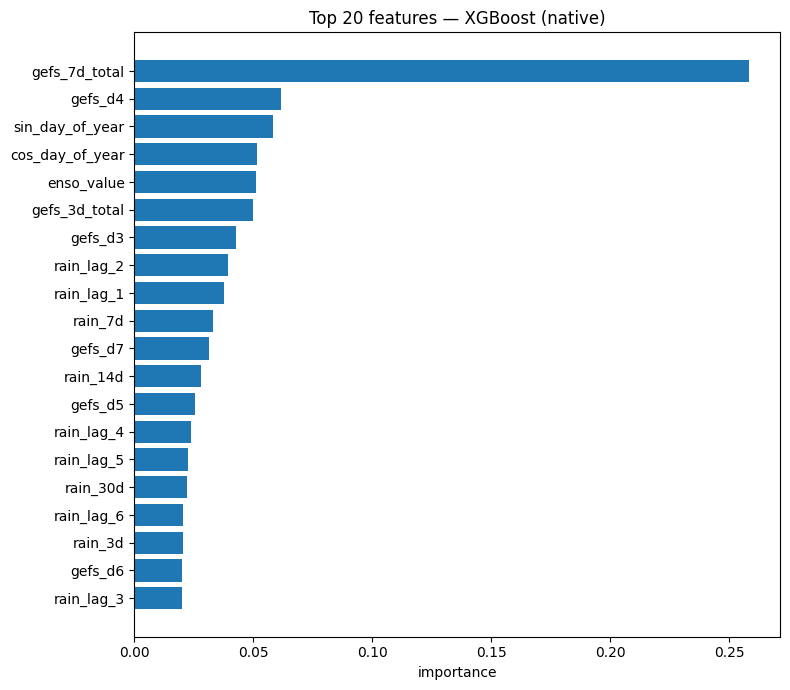


Note: feature importance indicates model reliance, not causal influence.


In [24]:
# Cell 25 — Native importance of the winner (top 20, validation-based permutation if unavailable)
import pandas as pd

IMP_MODEL_NAME = WINNER_NAME if WINNER_NAME in ESTIMATORS else BEST_ML_NAME
IMP_MODEL = ESTIMATORS[IMP_MODEL_NAME]
if IMP_MODEL_NAME != WINNER_NAME:
    print(f"Winner is rule-based ({WINNER_NAME}); showing best-ML ({IMP_MODEL_NAME}) importances as supplement.")
if hasattr(IMP_MODEL, "feature_importances_"):
    imp = pd.DataFrame({"feature": FEATURES,
                        "importance": np.asarray(IMP_MODEL.feature_importances_, float)})
    imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
    method = "native"
else:
    from sklearn.inspection import permutation_importance
    r = permutation_importance(IMP_MODEL, X_val, y_val, n_repeats=10, random_state=SEED, n_jobs=-1)
    imp = pd.DataFrame({"feature": FEATURES, "importance": r.importances_mean}).sort_values(
        "importance", ascending=False).reset_index(drop=True)
    method = "permutation (validation)"
print(f"method: {method} | importances from: {IMP_MODEL_NAME}")
print(imp.head(20).to_string(index=False))
top = imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top["feature"], top["importance"])
ax.set_xlabel("importance")
ax.set_title(f"Top 20 features — {IMP_MODEL_NAME} ({method})")
plt.tight_layout()
plt.show()
print("\nNote: feature importance indicates model reliance, not causal influence.")


## Error analysis of the winner (TEST data)

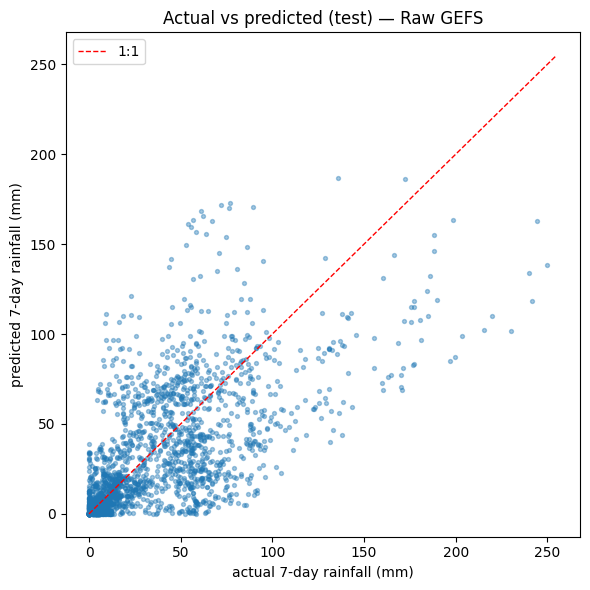

In [25]:
# Cell 26 — Actual vs predicted (test)
winner_test = winner_test_point
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, winner_test, s=8, alpha=0.4)
lim = [0, max(y_test.max(), winner_test.max()) * 1.02]
ax.plot(lim, lim, "r--", linewidth=1, label="1:1")
ax.set_xlabel("actual 7-day rainfall (mm)")
ax.set_ylabel("predicted 7-day rainfall (mm)")
ax.set_title(f"Actual vs predicted (test) — {WINNER_NAME}")
ax.legend()
plt.tight_layout()
plt.show()


mean -4.089 | median -1.484 | MAE 19.539 | RMSE 29.606


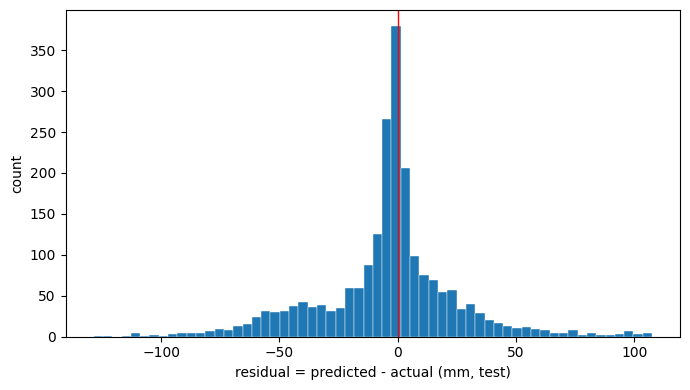

In [26]:
# Cell 27 — Residual distribution (test): residual = predicted - actual
resid_test = np.asarray(winner_test, float) - np.asarray(y_test, float)
print(f"mean {resid_test.mean():+.3f} | median {np.median(resid_test):+.3f} | "
      f"MAE {np.mean(np.abs(resid_test)):.3f} | RMSE {np.sqrt(np.mean(resid_test ** 2)):.3f}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(resid_test, bins=60, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="r", linewidth=1)
ax.set_xlabel("residual = predicted - actual (mm, test)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


In [27]:
# Cell 28 — Test MAE by block (all six Sangrur blocks)
test_eval = test_df[["forecast_date", "block"]].copy()
test_eval["actual"] = np.asarray(y_test, float)
test_eval["predicted"] = np.asarray(winner_test, float)
by_block = test_eval.groupby("block").apply(
    lambda g: mean_absolute_error(g["actual"], g["predicted"]), include_groups=False)
by_block = pd.DataFrame({"block": by_block.index, "test_MAE": by_block.values.round(3),
                         "n": test_eval["block"].value_counts().sort_index().values})
print(by_block.sort_values("block").to_string(index=False))


     block  test_MAE   n
     Dhuri    20.152 366
     Lehra    18.454 366
Malerkotla    20.291 366
    Moonak    17.749 366
   Sangrur    20.681 366
     Sunam    19.910 366


In [28]:
# Cell 29 — Test MAE by year (stability across unseen seasons)
test_eval["year"] = test_eval["forecast_date"].dt.year
by_year = test_eval.groupby("year").apply(
    lambda g: pd.Series({"test_MAE": round(mean_absolute_error(g["actual"], g["predicted"]), 3),
                         "mean_actual": round(g["actual"].mean(), 2), "n": len(g)}),
    include_groups=False)
print(by_year.to_string())


      test_MAE  mean_actual      n
year                              
2023    19.159        29.42  732.0
2024    17.400        28.07  732.0
2025    22.060        45.66  732.0


## Save artifacts (model + results + reload test + final report)

In [29]:
# Cell 30 — Output directories (create, never delete)
MODELS_DIR = PROJECT / "models"
RESULTS_DIR = PROJECT / "data" / "processed" / "model_results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"models/: {MODELS_DIR.resolve()}")
print(f"results/: {RESULTS_DIR.resolve()}")


models/: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\models
results/: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\processed\model_results


In [30]:
# Cell 31 — Save winning model (estimator, or baseline rule if a baseline won)
MODEL_PATH = MODELS_DIR / "best_model.joblib"
if WINNER_NAME in ESTIMATORS:
    joblib.dump(ESTIMATORS[WINNER_NAME], MODEL_PATH)
    print(f"saved estimator: {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.1f} KB) | model: {WINNER_NAME}")
else:
    rule = {"kind": "baseline", "name": WINNER_NAME}
    if WINNER_NAME == "Climatology":
        rule["doy_mean"] = {int(k): float(v) for k, v in doy_mean.items()}
        rule["global_mean"] = float(train_global_mean)
    elif WINNER_NAME == "Persistence":
        rule["column"] = "rain_7d"
    else:
        rule["column"] = "gefs_7d_total"
    joblib.dump(rule, MODEL_PATH)
    print(f"saved baseline rule: {MODEL_PATH} | model: {WINNER_NAME}")


saved baseline rule: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\models\best_model.joblib | model: Raw GEFS


In [31]:
# Cell 32 — Save results + metadata
comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
test_out = test_eval[["forecast_date", "block", "actual", "predicted"]].copy()
test_out["prob_low"], test_out["prob_normal"], test_out["prob_high"] = P_test.T
test_out["actual_category"], test_out["predicted_category"] = actual_test, pred_test_cat
test_out.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)
cat_metrics.to_csv(RESULTS_DIR / "category_metrics.csv", index=False)
imp.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)
(RESULTS_DIR / "category_thresholds.json").write_text(json.dumps(
    {"LOW_below_mm": T33, "HIGH_above_mm": T66, "method": "p33/p66 of TRAIN targets only",
     "T33": T33, "T66": T66}, indent=2))
metadata = {
    "selected_model": WINNER_NAME, "target": TARGET, "features": FEATURES,
    "train_dates": [str(train_df["forecast_date"].min().date()), str(train_df["forecast_date"].max().date())],
    "val_dates": [str(val_df["forecast_date"].min().date()), str(val_df["forecast_date"].max().date())],
    "test_dates": [str(test_df["forecast_date"].min().date()), str(test_df["forecast_date"].max().date())],
    "train_rows": len(train_df), "val_rows": len(val_df), "test_rows": len(test_df),
    "thresholds_mm": {"T33": T33, "T66": T66},
    "test_metrics": {k: float(test_row[k]) for k in ["MAE", "RMSE", "R2", "Bias"]},
    "category_metrics_test": {k: float(cat_metrics[cat_metrics["Split"] == "test"][k].iloc[0])
                              for k in ["accuracy", "macro_F1", "log_loss", "brier"]},
    "blocks": sorted(EXPECTED_BLOCKS), "random_seed": SEED,
    "model_path": str(MODEL_PATH), "data_path": str(DATA_PATH),
}
(RESULTS_DIR / "model_metadata.json").write_text(json.dumps(metadata, indent=2))
print("saved: model_comparison.csv, test_predictions.csv, category_metrics.csv,")
print("       feature_importance.csv, category_thresholds.json, model_metadata.json")
print(f"rows: comparison {len(comparison)}, test_predictions {len(test_out)}")


saved: model_comparison.csv, test_predictions.csv, category_metrics.csv,
       feature_importance.csv, category_thresholds.json, model_metadata.json
rows: comparison 12, test_predictions 2196


In [32]:
# Cell 33 — Reload test (artifact must reproduce predictions)
reloaded = joblib.load(MODEL_PATH)
sample = X_test.iloc[:50]
if isinstance(reloaded, dict):
    assert reloaded["name"] == WINNER_NAME, "rule/model mismatch"
    if reloaded["name"] == "Climatology":
        m = reloaded["doy_mean"]
        rp = np.array([m.get(d.dayofyear, reloaded["global_mean"])
                       for d in pd.to_datetime(test_df["forecast_date"].iloc[:50])])
    else:
        rp = test_df[reloaded["column"]].iloc[:50].to_numpy()
    assert np.allclose(rp, np.asarray(winner_test_point[:50], float), atol=1e-9)
    print(f"reload OK: baseline rule ({reloaded['name']}) reproduces 50-sample predictions within 1e-9")
else:
    assert type(reloaded).__name__ == type(ESTIMATORS[WINNER_NAME]).__name__
    assert np.allclose(reloaded.predict(sample), ESTIMATORS[WINNER_NAME].predict(sample), atol=1e-9)
    print(f"reload OK: {type(reloaded).__name__} reproduces 50-sample predictions within 1e-9")


reload OK: baseline rule (Raw GEFS) reproduces 50-sample predictions within 1e-9


In [33]:
# Cell 34 — Final model report
print("=" * 64)
print("FINAL MODEL REPORT (Notebook 04)")
print("=" * 64)
print(f"DATASET: {len(df)} rows, {len(FEATURES)} features, "
      f"{df['forecast_date'].nunique()} JJAS dates, 6 blocks ({', '.join(sorted(EXPECTED_BLOCKS))})")
print(f"SPLITS: train {len(train_df)} ({train_df['forecast_date'].nunique()} dates, JJAS 2016-19) | "
      f"val {len(val_df)} ({val_df['forecast_date'].nunique()} dates, JJAS 2021-22) | "
      f"test {len(test_df)} ({test_df['forecast_date'].nunique()} dates, JJAS 2023-25)")
b = comparison.pivot(index="Model", columns="Split", values="MAE")
print("\nBASELINES (test MAE): " + " | ".join(f"{m} {b.loc[m, 'test']:.3f}" for m in ["Climatology", "Persistence", "Raw GEFS"]))
print("ML (test MAE): " + " | ".join(f"{m} {b.loc[m, 'test']:.3f}" for m in ["Random Forest", "XGBoost", "LightGBM"]))
print(f"\nWINNER: {WINNER_NAME} | val MAE {val_mae.min():.3f} | test MAE {test_row['MAE']:.3f} | "
      f"RMSE {test_row['RMSE']:.3f} | R2 {test_row['R2']:.3f} | Bias {test_row['Bias']:.3f}")
print(f"  improvement vs climatology: {(clim_test_mae - test_row['MAE']) / clim_test_mae * 100:+.1f}% | "
      f"vs best baseline: {(best_base_test - test_row['MAE']) / best_base_test * 100:+.1f}%")
t = cat_metrics[cat_metrics["Split"] == "test"].iloc[0]
print(f"\nCATEGORIES: LOW<{T33:.2f} / HIGH>{T66:.2f} mm | accuracy {t['accuracy']:.3f} | macro F1 {t['macro_F1']:.3f} | "
      f"log loss {t['log_loss']:.3f} | brier {t['brier']:.3f}")
print(f"\nARTIFACT: {MODEL_PATH}")
print("=" * 64)


FINAL MODEL REPORT (Notebook 04)
DATASET: 6588 rows, 31 features, 1098 JJAS dates, 6 blocks (Dhuri, Lehra, Malerkotla, Moonak, Sangrur, Sunam)
SPLITS: train 2928 (488 dates, JJAS 2016-19) | val 1464 (244 dates, JJAS 2021-22) | test 2196 (366 dates, JJAS 2023-25)

BASELINES (test MAE): Climatology 24.640 | Persistence 30.536 | Raw GEFS 19.539
ML (test MAE): Random Forest 20.176 | XGBoost 21.082 | LightGBM 21.344

WINNER: Raw GEFS | val MAE 19.031 | test MAE 19.539 | RMSE 29.606 | R2 0.377 | Bias -4.089
  improvement vs climatology: +20.7% | vs best baseline: +0.0%

CATEGORIES: LOW<10.94 / HIGH>34.66 mm | accuracy 0.685 | macro F1 0.644 | log loss 2.078 | brier 1.087

ARTIFACT: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\models\best_model.joblib


## Inference artifacts for Notebook 05 (producer checks)

In [34]:
# Cell 35 — Inference artifacts for Notebook 05 (producer; alters no scientific results)
# Winner is the Raw GEFS rule. This cell only (re)saves artifacts in inference-safe form.
import json
import numpy as np
import pandas as pd
import joblib

THR = json.loads((RESULTS_DIR / "category_thresholds.json").read_text())
T33c, T66c = float(THR["T33"]), float(THR["T66"])
assert abs(T33c - T33) < 1e-9 and abs(T66c - T66) < 1e-9, "threshold drift vs Cell 21"

# 1. Probability calibration artifact: winner's TRAIN residual ECDF (training info only).
# NB04 Cell 23 method: P(low)=F(T33-p), P(high)=1-F(T66-p), F = ECDF(train residuals).
train_point = np.asarray(PREDS_TRAIN[WINNER_NAME], float)
resid_sorted = np.sort(np.asarray(y_train, float) - train_point)
CAL_PATH = MODELS_DIR / "probability_calibration.npz"
np.savez_compressed(CAL_PATH, residuals_sorted=resid_sorted,
                    T33=np.float64(T33c), T66=np.float64(T66c), eps=np.float64(1e-6),
                    method=np.array("residual_ecdf"),
                    fitted_on=np.array(f"train {train_df['forecast_date'].min().date()}..{train_df['forecast_date'].max().date()} ({len(train_df)} rows)"),
                    point_definition=np.array("winner point forecast + ECDF(train residuals); train-only"))
print(f"saved calibration: {CAL_PATH.name} (n_resid={len(resid_sorted)})")

# 2. Enriched best_model.joblib (keeps kind/name/column; adds explicit inference identity).
artifact = {"kind": "baseline", "model_type": "raw_gefs",
            "name": "Raw GEFS", "selected_method": "Raw CHIRPS-GEFS baseline",
            "column": "gefs_7d_total",
            "required_gefs_leads": [1, 2, 3, 4, 5, 6, 7],
            "forecast_horizon_days": 7,
            "spatial_unit": "Sangrur legacy Bhuvan blocks",
            "blocks": sorted(EXPECTED_BLOCKS),
            "target_definition": "actual CHIRPS rainfall D+1 through D+7",
            "thresholds_ref": "data/processed/model_results/category_thresholds.json",
            "calibration_ref": "models/probability_calibration.npz",
            "inference_config_ref": "models/inference_config.json",
            "note": "rule-based baseline, not an ML estimator: prediction = gefs_7d_total (sum of valid D+1..D+7 leads)"}
joblib.dump(artifact, MODEL_PATH)
print(f"saved enriched artifact: {MODEL_PATH.name} (model_type={artifact['model_type']})")

# 3. Enrich model_metadata.json (preserve existing keys; add inference keys + relative paths).
meta = json.loads((RESULTS_DIR / "model_metadata.json").read_text())
meta.update({"model_type": "raw_gefs", "selected_method": "Raw CHIRPS-GEFS baseline",
             "forecast_horizon_days": 7, "spatial_unit": "Sangrur legacy Bhuvan blocks",
             "required_gefs_leads": [1, 2, 3, 4, 5, 6, 7],
             "target_definition": "actual CHIRPS rainfall D+1 through D+7",
             "probability_method": "winner train-residual ECDF (Cell 23); params in models/probability_calibration.npz",
             "threshold_source": "training_only",
             "model_artifact": "models/best_model.joblib",
             "calibration_artifact": "models/probability_calibration.npz",
             "inference_config": "models/inference_config.json",
             "artifact_version": "nb04-2026-09-10",
             "required_input_datasets": ["CHIRPS-GEFS v3 daily (issue folder D, target files D+1..D+7)",
                                         "CHIRPS observations (context only, <=D)",
                                         "ENSO monthly index (context only)", "SoilGrids (static context)"]})
(RESULTS_DIR / "model_metadata.json").write_text(json.dumps(meta, indent=2))
print("enriched model_metadata.json (existing keys preserved)")

# 4. Dedicated inference config.
infer_config = {
    "selected_model_type": "raw_gefs",
    "selected_method": "Raw CHIRPS-GEFS baseline",
    "forecast_horizon_days": 7,
    "spatial_unit": "Sangrur legacy Bhuvan blocks",
    "blocks": sorted(EXPECTED_BLOCKS),
    "required_gefs_leads": [1, 2, 3, 4, 5, 6, 7],
    "lead_0_forbidden": True,
    "target_definition": "actual CHIRPS rainfall D+1 through D+7",
    "category_thresholds_mm": {"low_upper": T33c, "high_lower": T66c},
    "threshold_source": "training_only",
    "probability_method": "residual_ecdf",
    "probability_detail": "P(low)=F(T33-p), P(high)=1-F(T66-p) with F=ECDF of winner train residuals; train-only params",
    "calibration_artifact": "models/probability_calibration.npz",
    "model_artifact": "models/best_model.joblib",
    "required_input_datasets": meta["required_input_datasets"],
    "training_period": meta["train_dates"], "validation_period": meta["val_dates"],
    "test_period": meta["test_dates"],
    "feature_dataset": "data/processed/final_ml_dataset.parquet",
    "artifact_version": "nb04-2026-09-10",
    "random_seed": SEED,
}
CONFIG_PATH = MODELS_DIR / "inference_config.json"
CONFIG_PATH.write_text(json.dumps(infer_config, indent=2))
print(f"saved inference config: {CONFIG_PATH.name}")


saved calibration: probability_calibration.npz (n_resid=2928)
saved enriched artifact: best_model.joblib (model_type=raw_gefs)
enriched model_metadata.json (existing keys preserved)
saved inference config: inference_config.json


## Notebook 04 inference-readiness gate

In [35]:
# Cell 36 — Notebook 04 inference-readiness check (14 checks; exact print contract below)
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

checks = []
def check(name, cond):
    checks.append((name, bool(cond)))
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")

print("Inference-readiness checks:")
art = joblib.load(MODEL_PATH)
check("1. best_model.joblib exists", MODEL_PATH.exists())
check("2. artifact loads", art is not None)
check("3. method explicitly identifiable", isinstance(art, dict) and art.get("model_type") == "raw_gefs")
cfg = json.loads((MODELS_DIR / "inference_config.json").read_text())
check("4. inference_config exists", (MODELS_DIR / "inference_config.json").exists())
check("5. six legacy blocks exact", cfg.get("blocks") == ["Dhuri", "Lehra", "Malerkotla", "Moonak", "Sangrur", "Sunam"])
check("6. GEFS leads exactly 1-7", cfg.get("required_gefs_leads") == [1, 2, 3, 4, 5, 6, 7])
check("7. lead 0 absent", 0 not in cfg.get("required_gefs_leads", [0]) and cfg.get("lead_0_forbidden") is True)
thr = json.loads((RESULTS_DIR / "category_thresholds.json").read_text())
check("8. thresholds exist", abs(thr["T33"] - T33) < 1e-9 and abs(thr["T66"] - T66) < 1e-9)
cal = np.load(MODELS_DIR / "probability_calibration.npz")
check("9. calibration artifact exists", set(cal.files) >= {"residuals_sorted", "T33", "T66"}
      and len(cal["residuals_sorted"]) == len(y_train))
meta = json.loads((RESULTS_DIR / "model_metadata.json").read_text())
check("10. metadata exists", meta.get("model_type") == "raw_gefs" and meta.get("selected_method") == "Raw CHIRPS-GEFS baseline")
tp = pd.read_csv(RESULTS_DIR / "test_predictions.csv")
re_pred = np.asarray(test_df["gefs_7d_total"] if art.get("column") == "gefs_7d_total" else winner_test_point, float)
check("11. reload reproduces predictions", np.allclose(re_pred, tp["predicted"].to_numpy(), atol=1e-6))
check("12. calibration train-only", "train" in str(cal["fitted_on"]) and "2021" not in str(cal["fitted_on"]) and "2023" not in str(cal["fitted_on"]))
check("13. selected method is Raw GEFS", art.get("selected_method") == "Raw CHIRPS-GEFS baseline" and cfg.get("selected_model_type") == "raw_gefs")
check("14. NB05 artifact paths exist", all((PROJECT / p).exists() for p in
      [cfg["model_artifact"], cfg["calibration_artifact"], "data/processed/model_results/category_thresholds.json",
       "data/processed/model_results/model_metadata.json", "data/processed/model_results/test_predictions.csv"]))

ok = all(c for _, c in checks)
print()
if ok:
    print("=" * 60)
    print("NOTEBOOK 4 INFERENCE READINESS")
    print("=" * 60)
    print()
    print("Selected forecasting approach: Raw GEFS")
    print("Forecast horizon: 7 days")
    print("Spatial unit: 6 Sangrur legacy Bhuvan blocks")
    print()
    print("Artifact check: PASS")
    print("Metadata check: PASS")
    print("Probability/calibration check: PASS")
    print("Threshold check: PASS")
    print("Reload/reproducibility check: PASS")
    print("Leakage check: PASS")
    print("Inference configuration check: PASS")
    print()
    print("READY FOR NOTEBOOK 5")
    print()
    print("=" * 60)
else:
    print("=" * 60)
    print("NOTEBOOK 4 NOT READY")
    print("=" * 60)
    print("Failed checks:")
    for name, cond in checks:
        if not cond:
            print(f"  - {name}")
    raise SystemExit("Inference-readiness FAILED — fix listed checks, do NOT proceed to Notebook 5")


Inference-readiness checks:
  [PASS] 1. best_model.joblib exists
  [PASS] 2. artifact loads
  [PASS] 3. method explicitly identifiable
  [PASS] 4. inference_config exists
  [PASS] 5. six legacy blocks exact
  [PASS] 6. GEFS leads exactly 1-7
  [PASS] 7. lead 0 absent
  [PASS] 8. thresholds exist
  [PASS] 9. calibration artifact exists
  [PASS] 10. metadata exists
  [PASS] 11. reload reproduces predictions
  [PASS] 12. calibration train-only
  [PASS] 13. selected method is Raw GEFS
  [PASS] 14. NB05 artifact paths exist

NOTEBOOK 4 INFERENCE READINESS

Selected forecasting approach: Raw GEFS
Forecast horizon: 7 days
Spatial unit: 6 Sangrur legacy Bhuvan blocks

Artifact check: PASS
Metadata check: PASS
Probability/calibration check: PASS
Threshold check: PASS
Reload/reproducibility check: PASS
Leakage check: PASS
Inference configuration check: PASS

READY FOR NOTEBOOK 5

